In [118]:
import pandas as pd
import numpy as np
import ast
import matplotlib.pyplot as plt
from wordcloud import WordCloud

In [95]:
df_analysis = pd.read_csv("oscars_movies_merged.csv")

In [96]:
len(df_analysis)

2373

In [97]:
df_analysis["oscar_nominated"].mean()

np.float64(0.22334597555836494)

np.float64(0.0876527602191319)

In [99]:
genre_counts = df_analysis["main_genre"].value_counts()

genre_counts

main_genre
Action             463
Drama              448
Comedy             387
Adventure          173
Horror             170
Animation          132
Crime              113
Thriller           109
Science Fiction     95
Fantasy             75
Family              70
Romance             51
Mystery             28
War                 21
Documentary         12
Music               10
History              9
Western              7
Name: count, dtype: int64

In [100]:
valid_genres = genre_counts[genre_counts >= 30].index

In [101]:
df_genre_filtered = df_analysis[
    df_analysis["main_genre"].isin(valid_genres)
]

In [102]:
genre_rates = (
    df_genre_filtered
    .groupby("main_genre")["oscar_nominated"]
    .mean()
    .sort_values(ascending=False)
)

genre_rates

main_genre
Animation          0.393939
Drama              0.386161
Family             0.300000
Adventure          0.294798
Romance            0.235294
Science Fiction    0.231579
Fantasy            0.200000
Action             0.159827
Crime              0.159292
Comedy             0.129199
Thriller           0.119266
Horror             0.041176
Name: oscar_nominated, dtype: float64

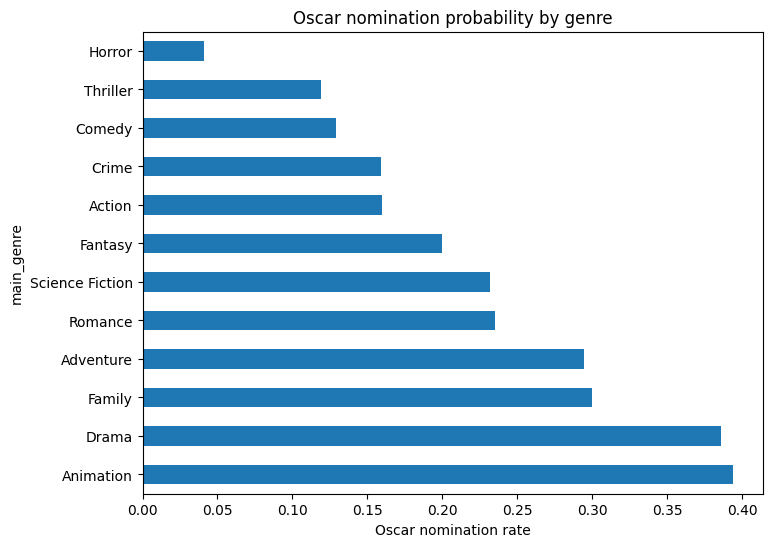

In [103]:
plt.figure(figsize=(8,6))

genre_rates.plot(kind="barh")

plt.xlabel("Oscar nomination rate")
plt.title("Oscar nomination probability by genre")

plt.show()

In [104]:
genre_stats = df_analysis.groupby("main_genre").agg(
    nomination_rate=("oscar_nominated","mean"),
    n_movies=("oscar_nominated","count")
)

genre_stats = genre_stats[genre_stats["n_movies"] >= 30]

genre_stats.sort_values("nomination_rate", ascending=False)

,nomination_rate,n_movies
main_genre,,
Animation,0.393939,132
Drama,0.386161,448
Family,0.300000,70
Adventure,0.294798,173
Romance,0.235294,51
Science Fiction,0.231579,95
Fantasy,0.200000,75
Action,0.159827,463
Crime,0.159292,113


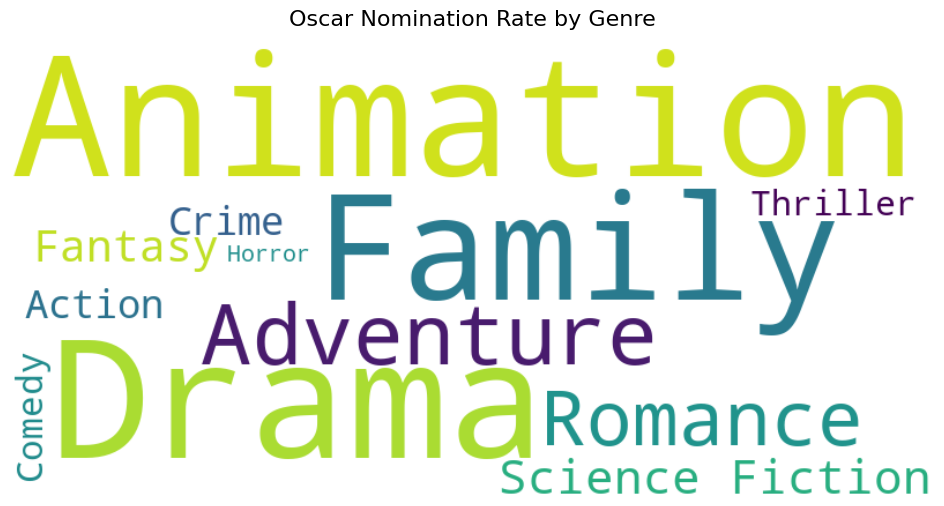

In [ ]:

genre_rates = df_genre_filtered.groupby("main_genre")["oscar_nominated"].mean()


genre_dict = genre_rates.to_dict()

wc = WordCloud(
    width=800,
    height=400,
    background_color="white",
    colormap="viridis"
).generate_from_frequencies(genre_dict)

plt.figure(figsize=(12,6))
plt.imshow(wc, interpolation="bilinear")
plt.axis("off")
plt.title("Oscar Nomination Rate by Genre", fontsize=16)
plt.show()

The analysis shows clear differences in Oscar nomination rates across film genres. Animated films and dramas have the highest nomination rates in the dataset, with roughly 39% of films receiving at least one Oscar nomination. Family and adventure films also show relatively high nomination rates of around 30%.

In contrast, genres such as action, crime, comedy, and thriller have noticeably lower nomination probabilities, generally between about 12% and 16%, while horror films have the lowest nomination rate at only about 4%.

It should be noted that animated films have their own dedicated Academy Award category (“Best Animated Feature”), which may partially explain the relatively high nomination rate observed for this genre.

In [105]:
df_analysis["log_budget"] = np.log(df_analysis["budget"])

In [106]:
df_analysis["budget_group"] = pd.qcut(df_analysis["budget"],5)

In [107]:
df_analysis.groupby("budget_group")["oscar_nominated"].mean()

budget_group
(0.999, 10000000.0]          0.097514
(10000000.0, 22000000.0]     0.175399
(22000000.0, 40000000.0]     0.200431
(40000000.0, 85000000.0]     0.256729
(85000000.0, 489900000.0]    0.398707
Name: oscar_nominated, dtype: float64

In [108]:
genre_counts = df_analysis["main_genre"].value_counts()

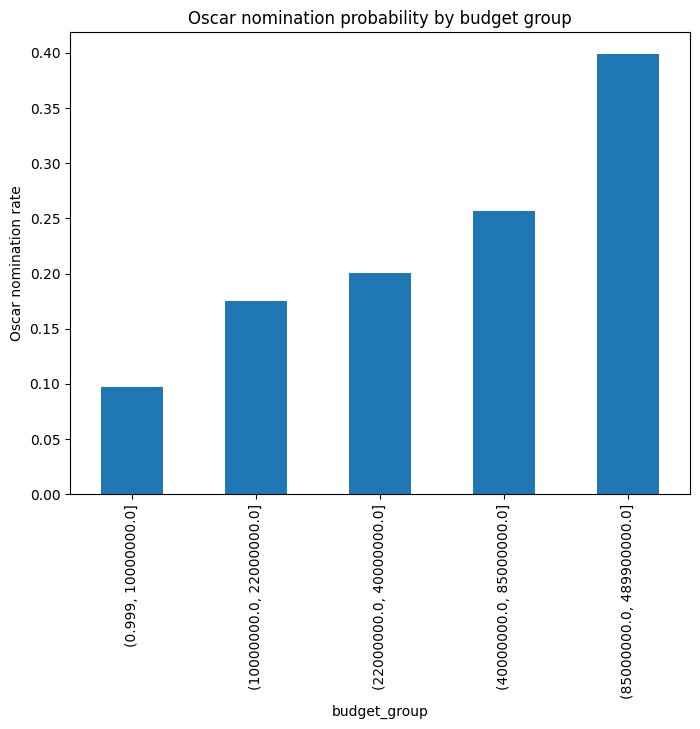

In [109]:
import matplotlib.pyplot as plt

budget_rates = df_analysis.groupby("budget_group")["oscar_nominated"].mean()

plt.figure(figsize=(8,6))
budget_rates.plot(kind="bar")

plt.ylabel("Oscar nomination rate")
plt.title("Oscar nomination probability by budget group")

plt.show()

The analysis also reveals a clear relationship between production budget and Oscar nomination rates. Films with smaller budgets (below $10 million) have a nomination rate of about 10%. As budgets increase, the likelihood of receiving an Oscar nomination also rises steadily.

Films with budgets between $40 million and $85 million show a nomination rate of around 26%, while the highest-budget films (above $85 million) have the highest nomination rate at approximately 40%.

Overall, the results suggest that higher-budget productions are considerably more likely to receive Oscar nominations than lower-budget films.

In [110]:
genre_counts = df_analysis["main_genre"].value_counts()

valid_genres = genre_counts[genre_counts >= 30].index

df_filtered = df_analysis[df_analysis["main_genre"].isin(valid_genres)]

In [111]:
df_filtered["budget_group"] = pd.qcut(df_filtered["budget"], 5)

In [112]:
genre_budget = (
    df_filtered
    .groupby(["main_genre", "budget_group"])["oscar_nominated"]
    .mean()
)

genre_budget

main_genre       budget_group             
Action           (0.999, 10000000.0]          0.018868
                 (10000000.0, 22000000.0]     0.016949
                 (22000000.0, 40000000.0]     0.097826
                 (40000000.0, 85000000.0]     0.171171
                 (85000000.0, 489900000.0]    0.297297
Adventure        (0.999, 10000000.0]          0.000000
                 (10000000.0, 22000000.0]     0.312500
                 (22000000.0, 40000000.0]     0.074074
                 (40000000.0, 85000000.0]     0.290323
                 (85000000.0, 489900000.0]    0.380435
Animation        (0.999, 10000000.0]          0.050000
                 (10000000.0, 22000000.0]     0.000000
                 (22000000.0, 40000000.0]     0.181818
                 (40000000.0, 85000000.0]     0.400000
                 (85000000.0, 489900000.0]    0.625000
Comedy           (0.999, 10000000.0]          0.105769
                 (10000000.0, 22000000.0]     0.110000
                 (2200

In [113]:
genre_budget_table = (
    df_filtered
    .groupby(["main_genre","budget_group"])["oscar_nominated"]
    .mean()
    .unstack()
)

genre_budget_table

budget_group,"(0.999, 10000000.0]","(10000000.0, 22000000.0]","(22000000.0, 40000000.0]","(40000000.0, 85000000.0]","(85000000.0, 489900000.0]"
main_genre,,,,,
Action,0.018868,0.016949,0.097826,0.171171,0.297297
Adventure,0.000000,0.312500,0.074074,0.290323,0.380435
Animation,0.050000,0.000000,0.181818,0.400000,0.625000
Comedy,0.105769,0.110000,0.130435,0.168831,0.214286
Crime,0.066667,0.083333,0.227273,0.200000,0.428571
Drama,0.189189,0.400000,0.489796,0.500000,0.733333
Family,0.142857,0.000000,0.153846,0.190476,0.608696
Fantasy,0.000000,0.285714,0.090909,0.176471,0.269231
Horror,0.000000,0.047619,0.033333,0.157895,0.333333


When considering both genre and budget simultaneously, the results show that higher production budgets generally increase the likelihood of receiving an Oscar nomination across most genres. This effect is particularly pronounced for dramatic films, where nomination rates rise from about 19% for low-budget productions to more than 70% for the highest-budget films.

A similar pattern can be observed for genres such as adventure and animation, where larger budgets are associated with substantially higher nomination probabilities. In contrast, genres like comedy and horror maintain relatively low nomination rates even at higher budget levels.

Overall, the results indicate that both genre and production budget play an important role in determining the likelihood of receiving an Oscar nomination.

In [114]:
genre_budget_stats = genre_budget_stats.reset_index()

In [115]:
genre_budget_stats = (
    df_filtered
    .groupby(["main_genre","budget_group"])
    .agg(
        nomination_rate=("oscar_nominated","mean"),
        n_movies=("oscar_nominated","count")
    )
    .reset_index()
)
genre_budget_stats = genre_budget_stats[
    genre_budget_stats["n_movies"] >= 5
]

In [116]:
genre_budget_matrix = genre_budget_stats.pivot(
    index="main_genre",
    columns="budget_group",
    values="nomination_rate"
)

genre_budget_matrix

budget_group,"(0.999, 10000000.0]","(10000000.0, 22000000.0]","(22000000.0, 40000000.0]","(40000000.0, 85000000.0]","(85000000.0, 489900000.0]"
main_genre,,,,,
Action,0.018868,0.016949,0.097826,0.171171,0.297297
Adventure,0.000000,0.312500,0.074074,0.290323,0.380435
Animation,0.050000,0.000000,0.181818,0.400000,0.625000
Comedy,0.105769,0.110000,0.130435,0.168831,0.214286
Crime,0.066667,0.083333,0.227273,0.200000,0.428571
Drama,0.189189,0.400000,0.489796,0.500000,0.733333
Family,0.142857,0.000000,0.153846,0.190476,0.608696
Fantasy,0.000000,0.285714,0.090909,0.176471,0.269231
Horror,0.000000,0.047619,0.033333,0.157895,NaN


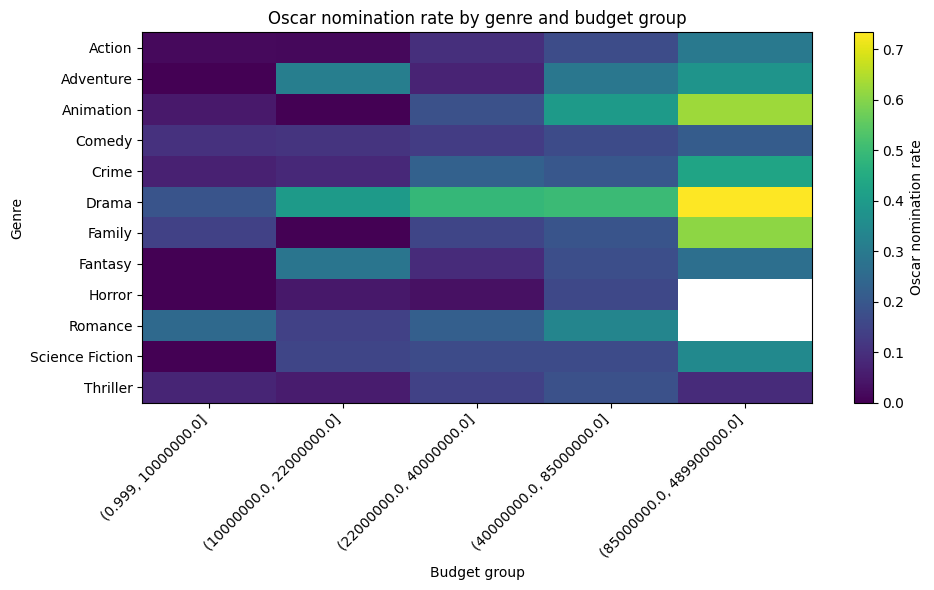

In [117]:
plt.figure(figsize=(10, 6))
plt.imshow(genre_budget_matrix, aspect="auto")
plt.colorbar(label="Oscar nomination rate")

plt.xticks(
    range(len(genre_budget_matrix.columns)),
    genre_budget_matrix.columns,
    rotation=45,
    ha="right"
)
plt.yticks(
    range(len(genre_budget_matrix.index)),
    genre_budget_matrix.index
)

plt.title("Oscar nomination rate by genre and budget group")
plt.xlabel("Budget group")
plt.ylabel("Genre")
plt.tight_layout()
plt.show()